## LLM judging Summary

Author: Heather Ho
Module: Codes_Heather_Ho/

Main steps:
- Write Rubrics as Rewards in LLM prompt
- Load prompt and dataset into LLM
- Plot results for number of PASSES and FAILS across different conditions:
    - basic prompt, rubric prompt, and same conditions but with normalized dataset
 



# Step 1: Write regular prompt and rubric prompt 
- Regular prompt: Contains a simple prompt asking the LLM to judge the inferred links
- Rubric prompt: Contains 9 detailed criterion with weights, and descriptions on the EU-ADR and Chemprot labels used

View prompts in Codes_Heather_Ho/prompts


# Step 2: load data

**filtered_inferred_links json from original project, and filtered_inferred_links_normalized_name.json from normalization step**

**Data is from this paper: Unified Biomedical Knowledge Extraction and Reasoning using Large Language**

Models and Knowledge Graphs
- This contains the json file of the multihop reasoning results
- Multihop traverses through more than one edge to find indirect relationships between nodes (entities)
- Contains the paths of the enities, the relations including the EU-ADR and Chemprot labels, and the inferred results
- This will be the input that goes into the LLM judge
- For more information on how the normalized json was made, go to Summary.ipynb in Code_Solhee_Tucker folder

View datasets in Codes_Heather_Ho/json_input

# Step 3: Create LLM judging function to load json file and prompt into openai
- Set the system prompt as the prompt text files I created
- Set the content as the inferred links json files
- Keep track of the paths and verdicts and print as the script runs
- view code in open_rubric_judging.py

# Step 4: Run the main script
- Get API key from openai
- Set as environment variable
- Set up a main scripts to run LLM judging on the basic prompt and rubric prompt
- Print comparison results and save results to text files
- Repeat steps to run the normalized dataset
- How to run the script: python llm_main.py 

# Step 5: Retrive results from llm_rubric and llm_basic and store in text files

View results in Codes_Heather_Ho/results

**Not normalized:**

Basic Prompt Results:

Passes: 25, Fails: 175, Total: 200

Rubric Prompt Results:

Passes: 3, Fails: 197, Total: 200

**Normalized:**

Basic Prompt Results:

Passes: 6, Fails: 194, Total: 200

Rubric Prompt Results:
Passes: 2, Fails: 198, Total: 200

# Step 6: Plot results

In [3]:
import pandas as pd

data = {
    'Model': ['openai_norm', 'openai_norm','openai_rubric_norm','openai_rubric_norm', 'openai', 'openai','openai_rubric' , 'openai_rubric'],
    'Score': [6 , 194, 2, 198, 25, 175, 3, 197],
    'Score type': ['Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail'],

}

df = pd.DataFrame(data)
df

,Model,Score,Score type
0,openai_norm,6,Pass
1,openai_norm,194,Fail
2,openai_rubric_norm,2,Pass
3,openai_rubric_norm,198,Fail
4,openai,25,Pass
5,openai,175,Fail
6,openai_rubric,3,Pass
7,openai_rubric,197,Fail


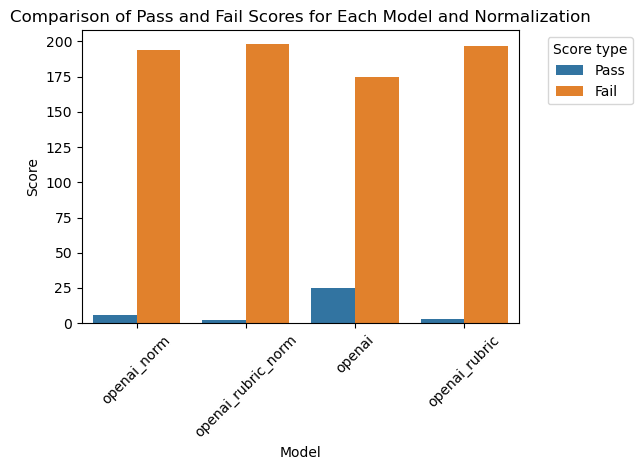

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
# graph passes and fails for each model separated by normalization
sns.barplot(x= 'Model', y= 'Score', data=df, hue='Score type')
# expand x-axis
plt.xticks(rotation=45)
plt.title('Comparison of Pass and Fail Scores for Each Model and Normalization')
plt.legend(title="Score type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 
plt.show()


# Additional sections

**Lessons learned**: describe what you learned from this project (anything at all).

Through revising the work of this paper, I learned the important of normalization and evaluation. Data that is unclear and noisy demonstrates less meaningful results. If you do not do throughout verification, there is no way to know that your novel approach is effective

**References** : citations are included in the presentation slides.

**Acknowledgements** : I got help from Professor Andreopoulos on the project idea, and how to implement a more rigorous LLM judging